In [4]:
import numpy as np 
import pandas as pd 
import matplotlib .pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_all_data
from src.feature_engineering import create_features

data = load_all_data()
orders = data["orders_medium"]
order_items = data["order_items (2)"]
customers = data["customers_medium"]
restaurants = data["restaurants"]
menu_items = data["menu_items"]

In [6]:
import os

FIGURE_PATH = "../../outputs/figures"

os.makedirs(FIGURE_PATH, exist_ok=True)

print("Figure output folder ready:", FIGURE_PATH)

Figure output folder ready: ../../outputs/figures


In [7]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

orders["order_time"] = pd.to_datetime(orders["order_time"])
orders["delivery_time"] = pd.to_datetime(orders["delivery_time"])

In [15]:
datasets = {
    "Customers": customers,
    "Menu Items": menu_items,
    "Order Items": order_items,
    "Orders": orders,
    "Restaurants": restaurants
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Customers: (1500, 3)
Menu Items: (400, 3)
Order Items: (12391, 4)
Orders: (5000, 13)
Restaurants: (120, 4)


In [16]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Customers
customer_id    0
city           0
signup_date    0
dtype: int64

Menu Items
item_id          0
restaurant_id    0
price            0
dtype: int64

Order Items
order_id    0
item_id     0
quantity    0
price       0
dtype: int64

Orders
order_id                 0
customer_id              0
restaurant_id            0
order_time               0
delivery_time            0
status                   0
order_date               0
order_year               0
order_month              0
order_month_name         0
order_day                0
order_hour               0
delivery_time_minutes    0
dtype: int64

Restaurants
restaurant_id    0
cuisine          0
city             0
rating           0
dtype: int64


In [17]:
for name, df in datasets.items():
    print(
        f"{name}: {df.duplicated().sum()} duplicate rows"
    )

Customers: 0 duplicate rows
Menu Items: 0 duplicate rows
Order Items: 0 duplicate rows
Orders: 0 duplicate rows
Restaurants: 0 duplicate rows


In [18]:
orders["order_date"] = orders["order_time"].dt.date
orders["order_year"] = orders["order_time"].dt.year
orders["order_month"] = orders["order_time"].dt.month
orders["order_month_name"] = orders["order_time"].dt.month_name()
orders["order_day"] = orders["order_time"].dt.day_name()
orders["order_hour"] = orders["order_time"].dt.hour

In [19]:
orders["delivery_time_minutes"] = (
    orders["delivery_time"] - orders["order_time"]
).dt.total_seconds() / 60

In [20]:
orders[
    [
        "order_time",
        "delivery_time",
        "order_hour",
        "delivery_time_minutes"
    ]
].head()

,order_time,delivery_time,order_hour,delivery_time_minutes
0,2023-01-17,2023-01-17 00:43:00,0,43.0
1,2023-04-24,2023-04-24 00:33:00,0,33.0
2,2024-01-17,2024-01-17 00:29:00,0,29.0
3,2023-03-27,2023-03-27 00:31:00,0,31.0
4,2024-01-09,2024-01-09 01:02:00,0,62.0


In [21]:
status_counts = orders["status"].value_counts()

status_counts

status
Delivered    1717
Late         1671
Cancelled    1612
Name: count, dtype: int64

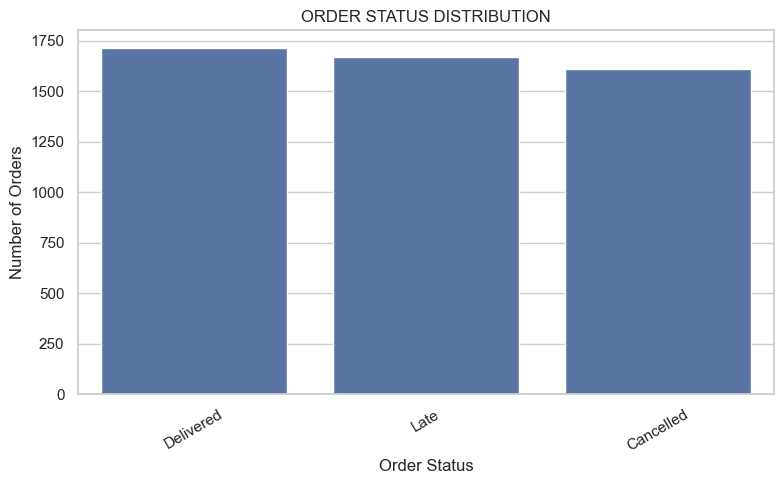

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="status",
    order=orders["status"].value_counts().index
)

plt.title("ORDER STATUS DISTRIBUTION")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [23]:
daily_orders = (
    orders
    .groupby("order_date")
    .size()
    .reset_index(name="total_orders")
)

daily_orders.head()

,order_date,total_orders
0,2023-01-01,15
1,2023-01-02,5
2,2023-01-03,13
3,2023-01-04,8
4,2023-01-05,14


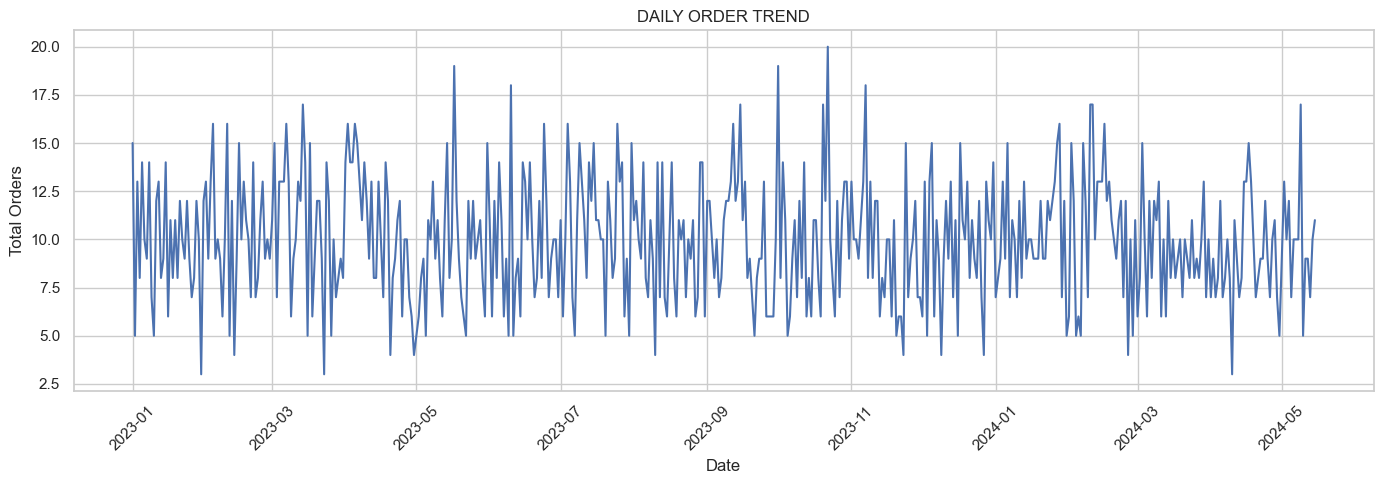

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_orders["order_date"],
    daily_orders["total_orders"]
)

plt.title("DAILY ORDER TREND")
plt.xlabel("Date")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/daily_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [25]:
monthly_orders = (
    orders
    .groupby(
        [
            "order_year",
            "order_month"
        ]
    )
    .size()
    .reset_index(
        name="total_orders"
    )
)

monthly_orders.head()

,order_year,order_month,total_orders
0,2023,1,304
1,2023,2,288
2,2023,3,326
3,2023,4,320
4,2023,5,295


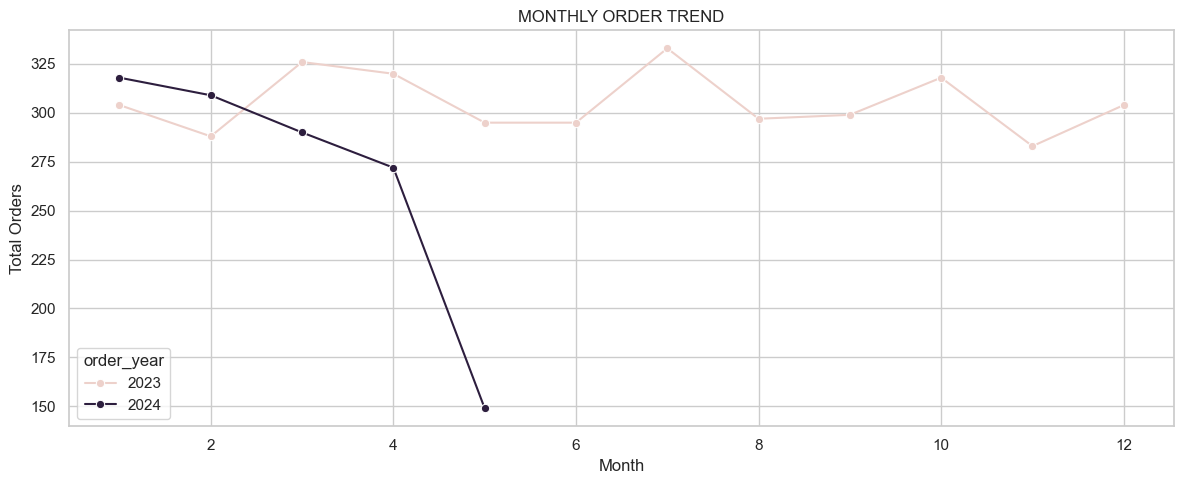

In [26]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_month",
    y="total_orders",
    hue="order_year",
    marker="o"
)

plt.title("MONTHLY ORDER TREND")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/monthly_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [30]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_orders = (
    orders
    .groupby("order_day")
    .size()
    .reindex(day_order)
    .reset_index(
        name="total_orders"
    )
)

weekly_orders

,order_day,total_orders
0,Monday,664
1,Tuesday,743
2,Wednesday,697
3,Thursday,700
4,Friday,691
5,Saturday,739
6,Sunday,766


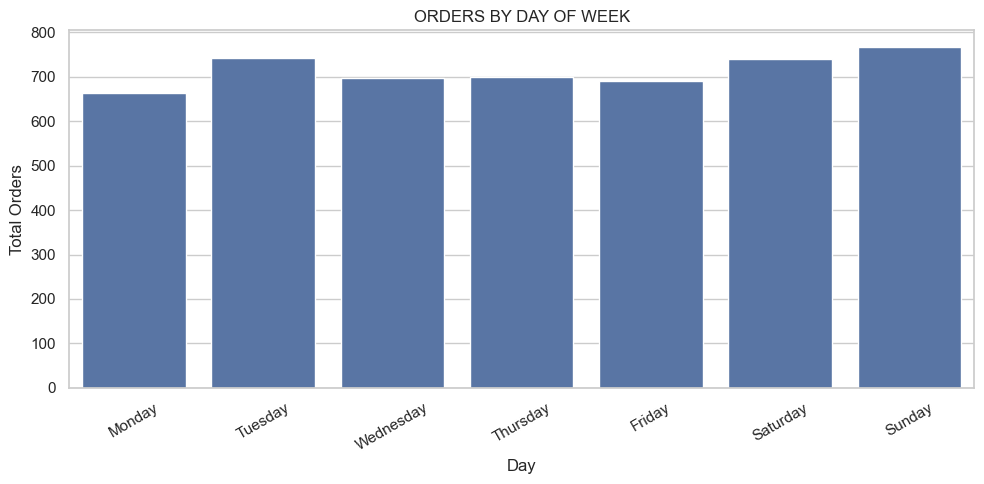

In [31]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekly_orders,
    x="order_day",
    y="total_orders"
)

plt.title("ORDERS BY DAY OF WEEK")
plt.xlabel("Day")
plt.ylabel("Total Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/orders_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [32]:
order_items["item_revenue"] = (
    order_items["quantity"] *
    order_items["price"]
)

order_items.head()

,order_id,item_id,quantity,price,item_revenue
0,O00001,M0197,2,7.93,15.86
1,O00001,M0223,1,14.20,14.20
2,O00001,M0196,3,26.56,79.68
3,O00001,M0326,3,6.03,18.09
4,O00002,M0172,3,35.65,106.95


In [34]:
total_revenue = (
    order_items["item_revenue"].sum()
)

print(
    f"Total Revenue: "
    f"{total_revenue:,.2f}")

Total Revenue: 560,509.15


In [35]:
order_revenue = (
    order_items
    .groupby("order_id")["item_revenue"]
    .sum()
    .reset_index(
        name="order_revenue"
    )
)

order_revenue.head()

,order_id,order_revenue
0,O00001,127.83
1,O00002,228.94
2,O00003,62.99
3,O00004,116.66
4,O00005,112.99


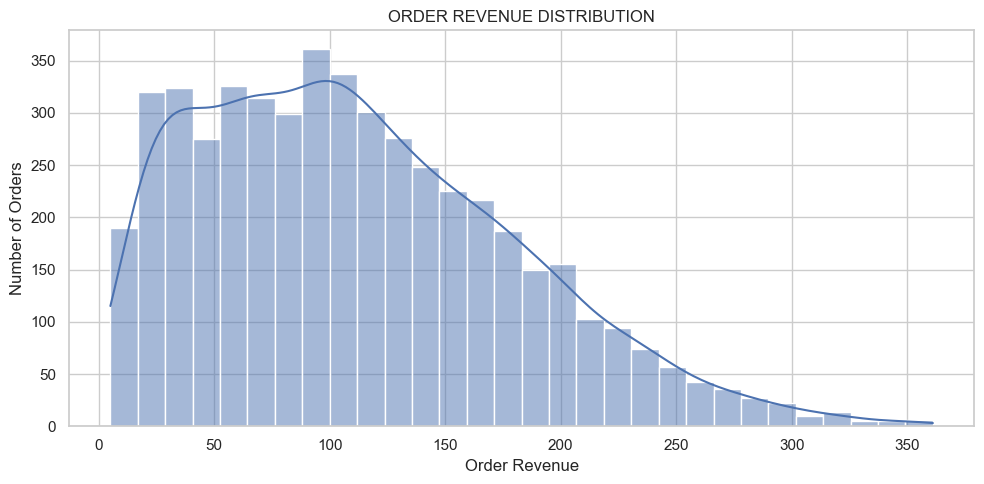

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=order_revenue,
    x="order_revenue",
    bins=30,
    kde=True
)

plt.title("ORDER REVENUE DISTRIBUTION")
plt.xlabel("Order Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/order_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [37]:
revenue_data = (
    order_items
    .merge(
        orders[
            [
                "order_id",
                "order_time",
                "order_year",
                "order_month"
            ]
        ],
        on="order_id",
        how="left"
    )
)

revenue_data.head()

,order_id,item_id,quantity,price,item_revenue,order_time,order_year,order_month
0,O00001,M0197,2,7.93,15.86,2023-01-17,2023,1
1,O00001,M0223,1,14.20,14.20,2023-01-17,2023,1
2,O00001,M0196,3,26.56,79.68,2023-01-17,2023,1
3,O00001,M0326,3,6.03,18.09,2023-01-17,2023,1
4,O00002,M0172,3,35.65,106.95,2023-04-24,2023,4


In [38]:
monthly_revenue = (
    revenue_data
    .groupby(
        [
            "order_year",
            "order_month"
        ]
    )["item_revenue"]
    .sum()
    .reset_index(
        name="total_revenue"
    )
)

monthly_revenue.head()

,order_year,order_month,total_revenue
0,2023,1,33453.28
1,2023,2,30887.60
2,2023,3,35970.92
3,2023,4,36117.04
4,2023,5,33419.53


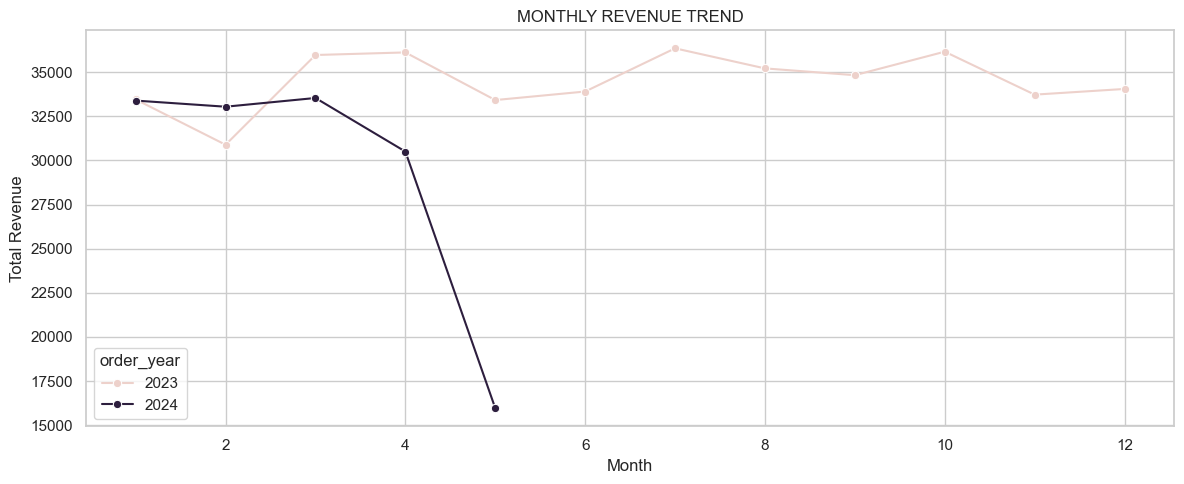

In [39]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="order_month",
    y="total_revenue",
    hue="order_year",
    marker="o"
)

plt.title("MONTHLY REVENUE TREND")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [42]:
revenue_day = (
    revenue_data
    .merge(
        orders[
            [
                "order_id",
                "order_day"
            ]
        ],
        on="order_id",
        how="left"
    )
    .groupby("order_day")["item_revenue"]
    .sum()
    .reindex(day_order)
    .reset_index(
        name="total_revenue"
    )
)

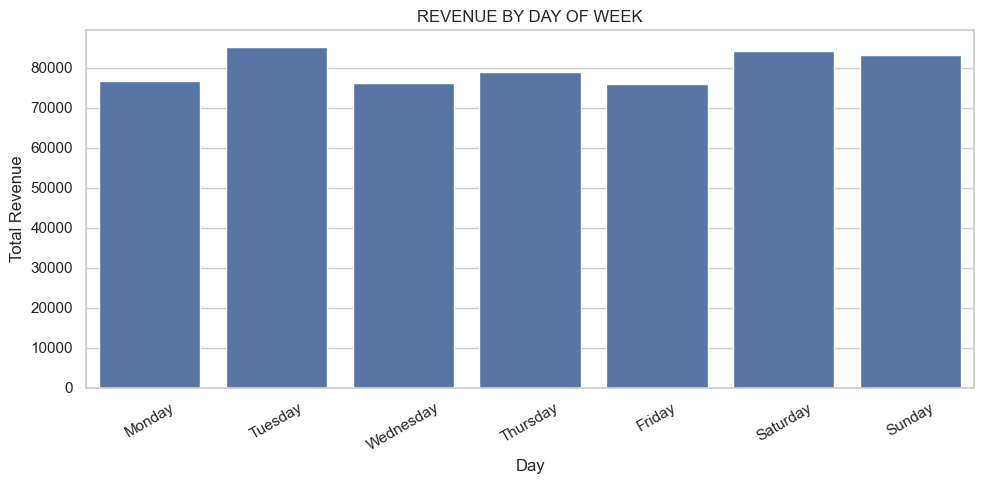

In [43]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=revenue_day,
    x="order_day",
    y="total_revenue"
)

plt.title("REVENUE BY DAY OF WEEK")
plt.xlabel("Day")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/revenue_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [44]:
total_orders = (
    orders["order_id"].nunique()
)

aov = (
    total_revenue /
    total_orders
)

print(
    f"Average Order Value: "
    f"{aov:.2f}"
)

Average Order Value: 112.10


In [45]:
active_customers = (
    orders["customer_id"].nunique()
)

total_customers = (
    customers["customer_id"].nunique()
)

inactive_customers = (
    total_customers -
    active_customers
)

customer_activity = pd.DataFrame({
    "customer_type": [
        "Active",
        "Inactive"
    ],
    "customer_count": [
        active_customers,
        inactive_customers
    ]
})

customer_activity

,customer_type,customer_count
0,Active,1452
1,Inactive,48


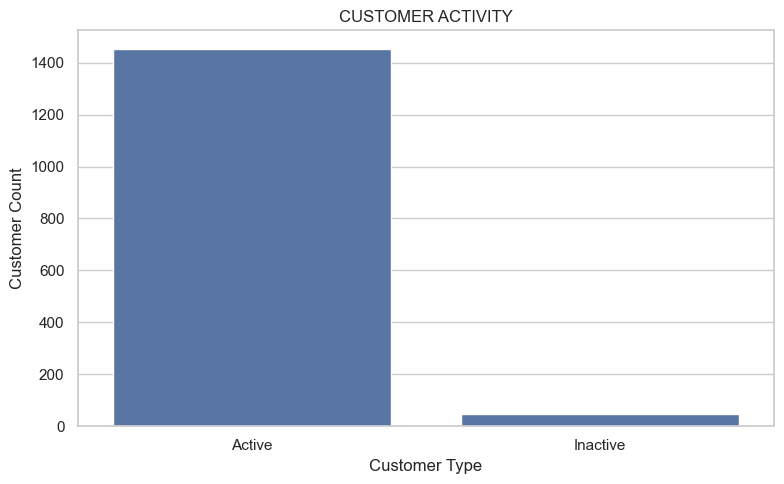

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_activity,
    x="customer_type",
    y="customer_count"
)

plt.title("CUSTOMER ACTIVITY")
plt.xlabel("Customer Type")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/customer_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [47]:
customer_orders = (
    orders
    .groupby("customer_id")
    .size()
    .reset_index(
        name="total_orders"
    )
)

customer_orders.head()

,customer_id,total_orders
0,C0001,4
1,C0002,5
2,C0003,5
3,C0004,1
4,C0005,3


In [48]:
customer_orders["customer_type"] = np.where(
    customer_orders["total_orders"] == 1,
    "One-Time Customer",
    "Repeat Customer"
)

customer_frequency = (
    customer_orders["customer_type"]
    .value_counts()
    .reset_index()
)

customer_frequency.columns = [
    "customer_type",
    "customer_count"
]

customer_frequency

,customer_type,customer_count
0,Repeat Customer,1272
1,One-Time Customer,180


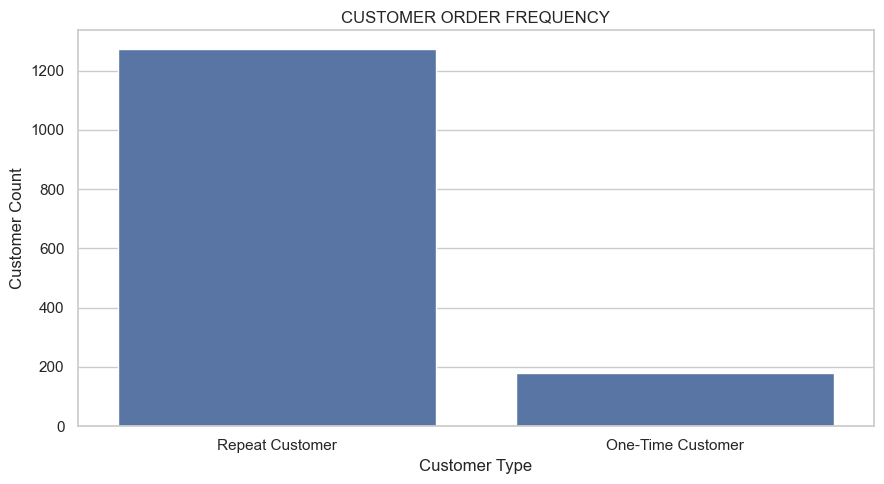

In [49]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=customer_frequency,
    x="customer_type",
    y="customer_count"
)

plt.title("CUSTOMER ORDER FREQUENCY")
plt.xlabel("Customer Type")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/customer_order_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [50]:
customer_revenue = (
    revenue_data
    .merge(
        orders[
            [
                "order_id",
                "customer_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")["item_revenue"]
    .sum()
    .reset_index(
        name="total_revenue"
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

top_customers = (
    customer_revenue
    .head(10)
)

top_customers

,customer_id,total_revenue
1398,C1447,1527.70
1028,C1065,1399.37
980,C1017,1272.65
1134,C1176,1175.32
1235,C1281,1169.58
1137,C1179,1145.86
1125,C1166,1128.45
1172,C1215,1124.42
461,C0482,1104.36
826,C0860,1085.66


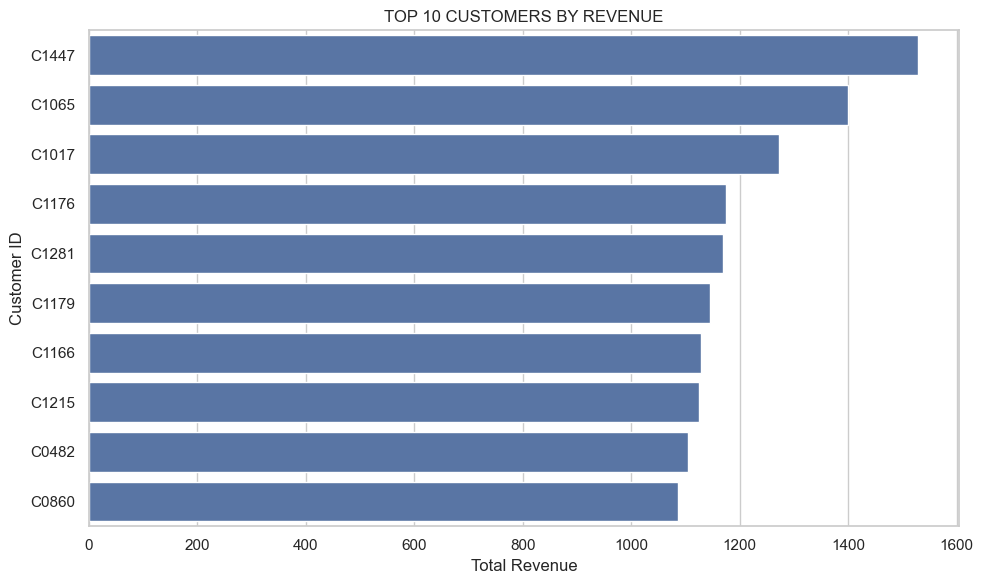

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    y="customer_id",
    x="total_revenue"
)

plt.title("TOP 10 CUSTOMERS BY REVENUE")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/top_customers_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [52]:
restaurant_orders = (
    orders
    .merge(
        restaurants,
        on="restaurant_id",
        how="left"
    )
)

restaurant_orders.head()

,order_id,customer_id,restaurant_id,order_time,delivery_time,status,order_date,order_year,order_month,order_month_name,order_day,order_hour,delivery_time_minutes,cuisine,city,rating
0,O00001,C1234,R041,2023-01-17,2023-01-17 00:43:00,Late,2023-01-17,2023,1,January,Tuesday,0,43.0,Italian,Manchester,4.9
1,O00002,C1017,R019,2023-04-24,2023-04-24 00:33:00,Cancelled,2023-04-24,2023,4,April,Monday,0,33.0,Italian,London,4.1
2,O00003,C0488,R045,2024-01-17,2024-01-17 00:29:00,Cancelled,2024-01-17,2024,1,January,Wednesday,0,29.0,Indian,Manchester,4.1
3,O00004,C1452,R086,2023-03-27,2023-03-27 00:31:00,Late,2023-03-27,2023,3,March,Monday,0,31.0,Chinese,Leeds,4.9
4,O00005,C0915,R002,2024-01-09,2024-01-09 01:02:00,Cancelled,2024-01-09,2024,1,January,Tuesday,0,62.0,Chinese,Leeds,4.1


In [53]:
cuisine_orders = (
    restaurant_orders
    .groupby("cuisine")
    .size()
    .reset_index(
        name="total_orders"
    )
    .sort_values(
        "total_orders",
        ascending=False
    )
)

cuisine_orders

,cuisine,total_orders
5,Thai,1111
2,Indian,902
0,American,821
4,Mexican,819
3,Italian,812
1,Chinese,535


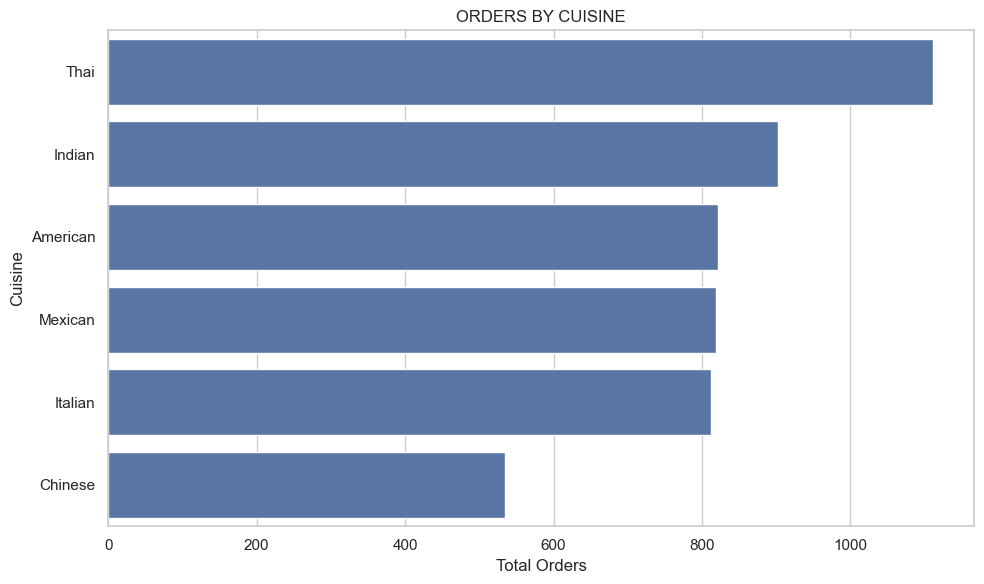

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cuisine_orders,
    y="cuisine",
    x="total_orders"
)

plt.title("ORDERS BY CUISINE")
plt.xlabel("Total Orders")
plt.ylabel("Cuisine")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/orders_by_cuisine.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [55]:
revenue_cuisine = (
    revenue_data
    .merge(
        orders[
            [
                "order_id",
                "restaurant_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[
            [
                "restaurant_id",
                "cuisine"
            ]
        ],
        on="restaurant_id",
        how="left"
    )
    .groupby("cuisine")["item_revenue"]
    .sum()
    .reset_index(
        name="total_revenue"
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

revenue_cuisine

,cuisine,total_revenue
5,Thai,127428.71
2,Indian,102630.54
0,American,90864.14
4,Mexican,90060.25
3,Italian,89963.60
1,Chinese,59561.91


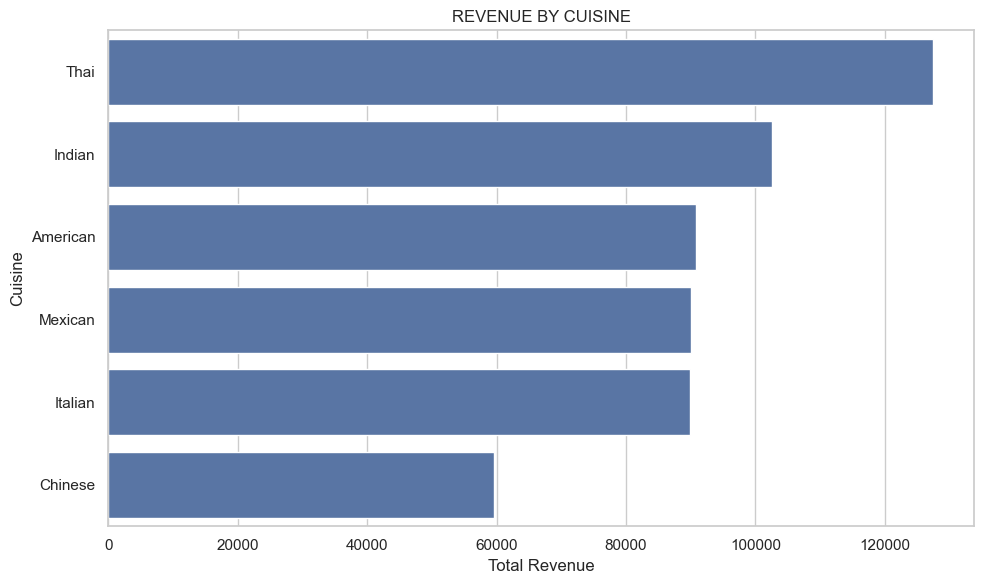

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_cuisine,
    y="cuisine",
    x="total_revenue"
)

plt.title("REVENUE BY CUISINE")
plt.xlabel("Total Revenue")
plt.ylabel("Cuisine")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/revenue_by_cuisine.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [57]:
top_restaurants_orders = (
    restaurant_orders
    .groupby("restaurant_id")
    .size()
    .reset_index(
        name="total_orders"
    )
    .sort_values(
        "total_orders",
        ascending=False
    )
    .head(10)
)

top_restaurants_orders

,restaurant_id,total_orders
20,R021,57
59,R060,56
37,R038,55
21,R022,55
95,R096,54
87,R088,54
73,R074,53
31,R032,53
45,R046,53
77,R078,51


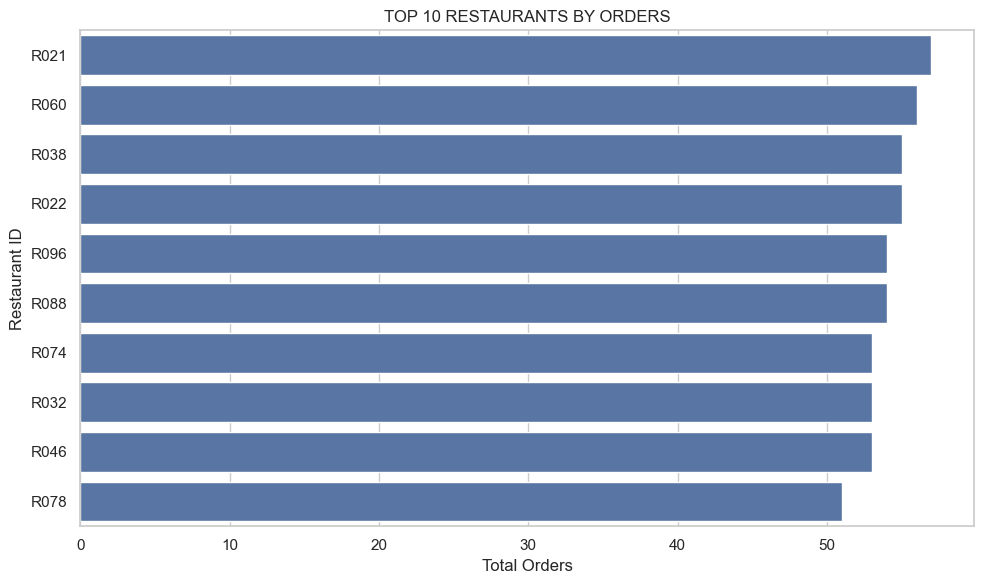

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_restaurants_orders,
    y="restaurant_id",
    x="total_orders"
)

plt.title("TOP 10 RESTAURANTS BY ORDERS")
plt.xlabel("Total Orders")
plt.ylabel("Restaurant ID")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/top_restaurants_by_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [59]:
restaurant_revenue = (
    revenue_data
    .merge(
        orders[
            [
                "order_id",
                "restaurant_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .groupby("restaurant_id")["item_revenue"]
    .sum()
    .reset_index(
        name="total_revenue"
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

top_restaurants_revenue = (
    restaurant_revenue.head(10)
)

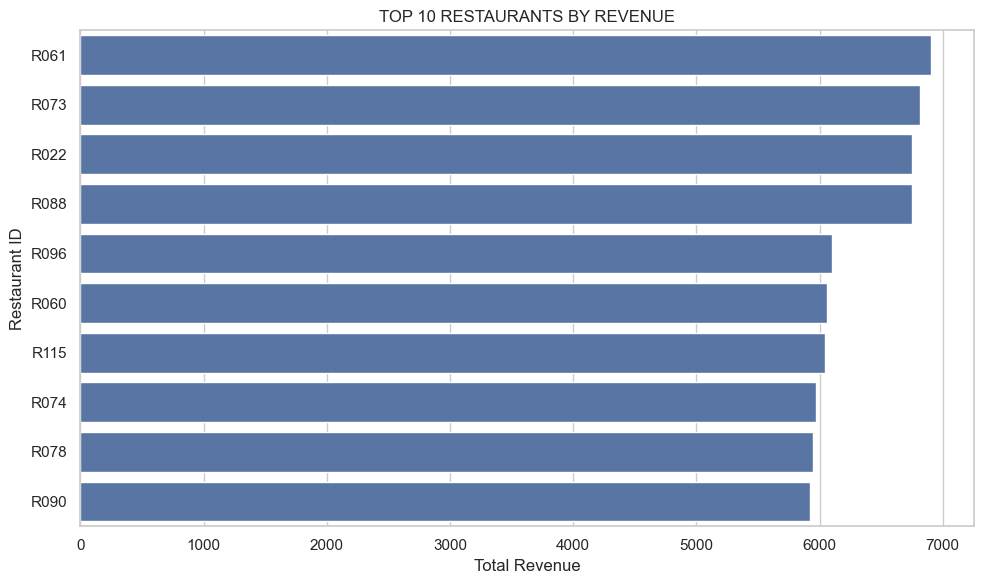

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_restaurants_revenue,
    y="restaurant_id",
    x="total_revenue"
)

plt.title("TOP 10 RESTAURANTS BY REVENUE")
plt.xlabel("Total Revenue")
plt.ylabel("Restaurant ID")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/top_restaurants_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [61]:
restaurant_rating_orders = (
    restaurant_orders
    .groupby(
        [
            "restaurant_id",
            "rating"
        ]
    )
    .agg(
        total_orders=(
            "order_id",
            "count"
        )
    )
    .reset_index()
)

restaurant_rating_orders.head()

,restaurant_id,rating,total_orders
0,R001,3.4,40
1,R002,4.1,29
2,R003,4.1,47
3,R004,3.5,35
4,R005,4.3,32


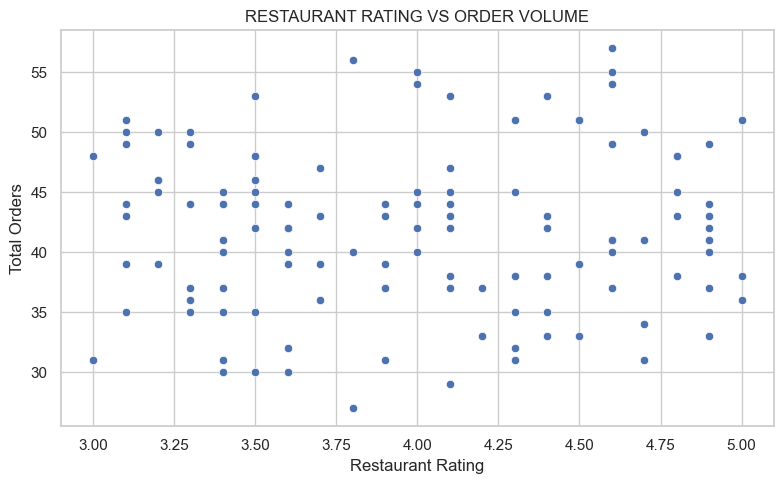

In [62]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=restaurant_rating_orders,
    x="rating",
    y="total_orders"
)

plt.title("RESTAURANT RATING VS ORDER VOLUME")
plt.xlabel("Restaurant Rating")
plt.ylabel("Total Orders")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/rating_vs_order_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [63]:
delivery_data = orders[
    orders["delivery_time_minutes"].notna()
]

delivery_data[
    "delivery_time_minutes"
].describe()

count    5000.000000
mean       54.624800
std        20.488172
min        20.000000
25%        37.000000
50%        55.000000
75%        72.000000
max        90.000000
Name: delivery_time_minutes, dtype: float64

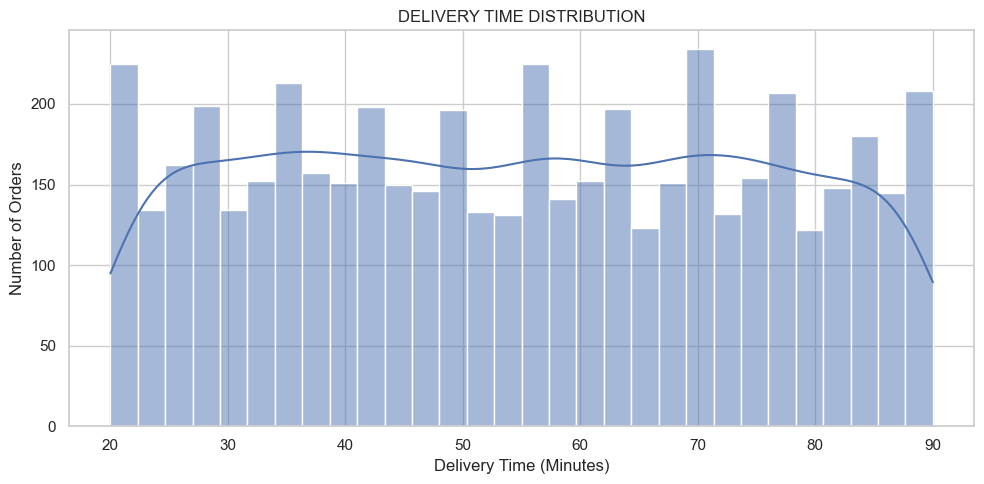

In [64]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivery_data,
    x="delivery_time_minutes",
    bins=30,
    kde=True
)

plt.title("DELIVERY TIME DISTRIBUTION")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [65]:
slowest_restaurants = (
    orders
    .groupby("restaurant_id")
    ["delivery_time_minutes"]
    .mean()
    .reset_index(
        name="avg_delivery_time"
    )
    .sort_values(
        "avg_delivery_time",
        ascending=False
    )
    .head(10)
)

slowest_restaurants

,restaurant_id,avg_delivery_time
63,R064,63.022727
71,R072,61.525000
16,R017,60.577778
50,R051,60.020000
6,R007,59.805556
36,R037,59.057143
39,R040,58.954545
68,R069,58.770833
20,R021,58.666667
96,R097,58.645833


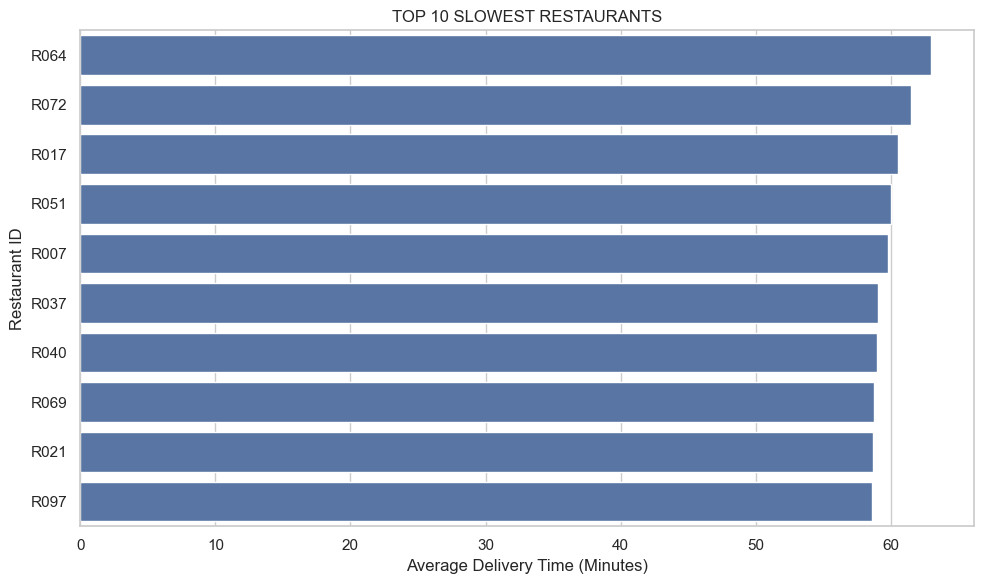

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=slowest_restaurants,
    y="restaurant_id",
    x="avg_delivery_time"
)

plt.title("TOP 10 SLOWEST RESTAURANTS")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Restaurant ID")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/slowest_restaurants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [67]:
delivery_city = (
    orders
    .merge(
        customers[
            [
                "customer_id",
                "city"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .groupby("city")
    ["delivery_time_minutes"]
    .mean()
    .reset_index(
        name="avg_delivery_time"
    )
    .sort_values(
        "avg_delivery_time",
        ascending=False
    )
)

delivery_city

,city,avg_delivery_time
0,Birmingham,55.370138
1,Bristol,55.259645
3,Liverpool,55.226322
4,London,54.079800
5,Manchester,53.907692
2,Leeds,53.805654


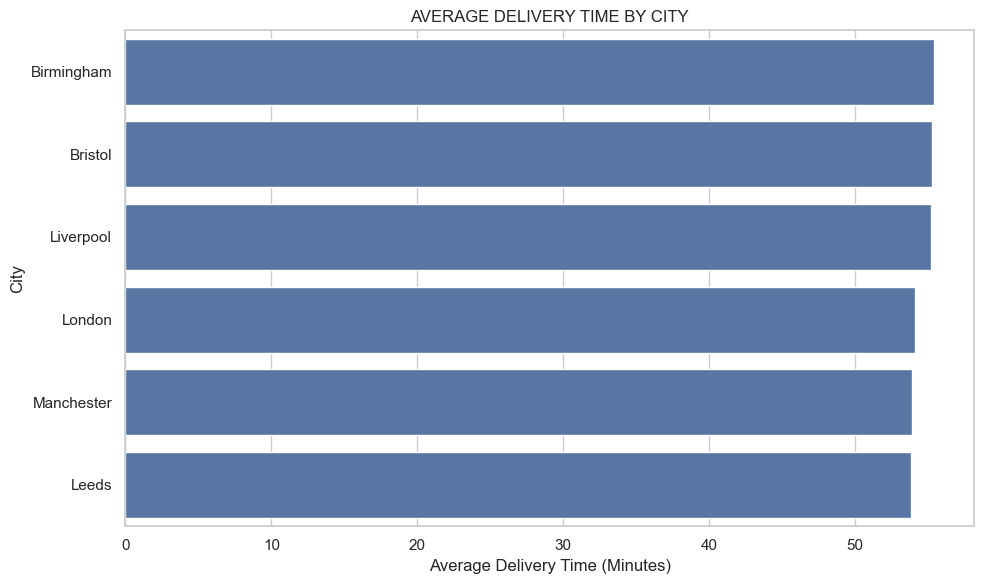

In [68]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=delivery_city,
    y="city",
    x="avg_delivery_time"
)

plt.title("AVERAGE DELIVERY TIME BY CITY")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/delivery_time_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

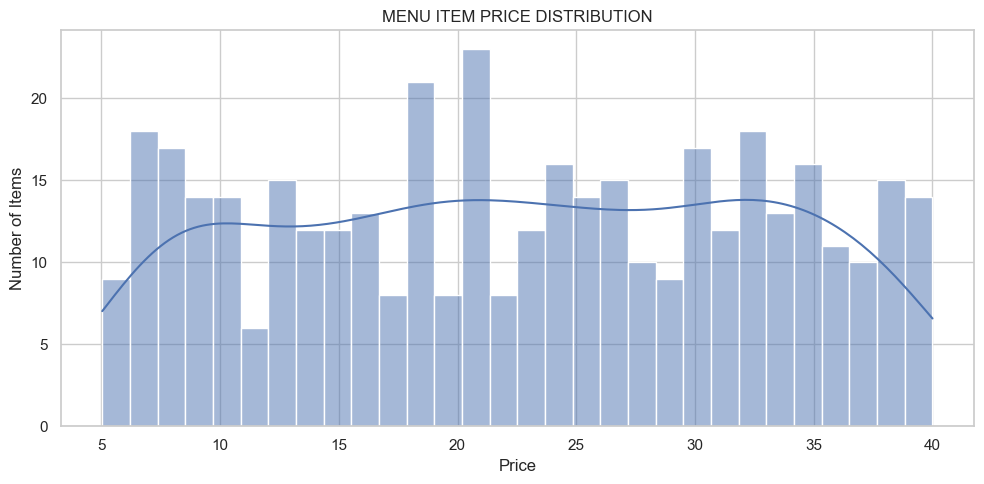

In [69]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=menu_items,
    x="price",
    bins=30,
    kde=True
)

plt.title("MENU ITEM PRICE DISTRIBUTION")
plt.xlabel("Price")
plt.ylabel("Number of Items")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/menu_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [70]:
item_sales = (
    order_items
    .groupby("item_id")["quantity"]
    .sum()
    .reset_index(
        name="total_quantity_sold"
    )
    .sort_values(
        "total_quantity_sold",
        ascending=False
    )
)

top_items = item_sales.head(10)

top_items

,item_id,total_quantity_sold
244,M0245,102
199,M0200,100
107,M0108,98
58,M0059,94
154,M0155,93
27,M0028,92
342,M0343,92
276,M0277,91
230,M0231,90
119,M0120,90


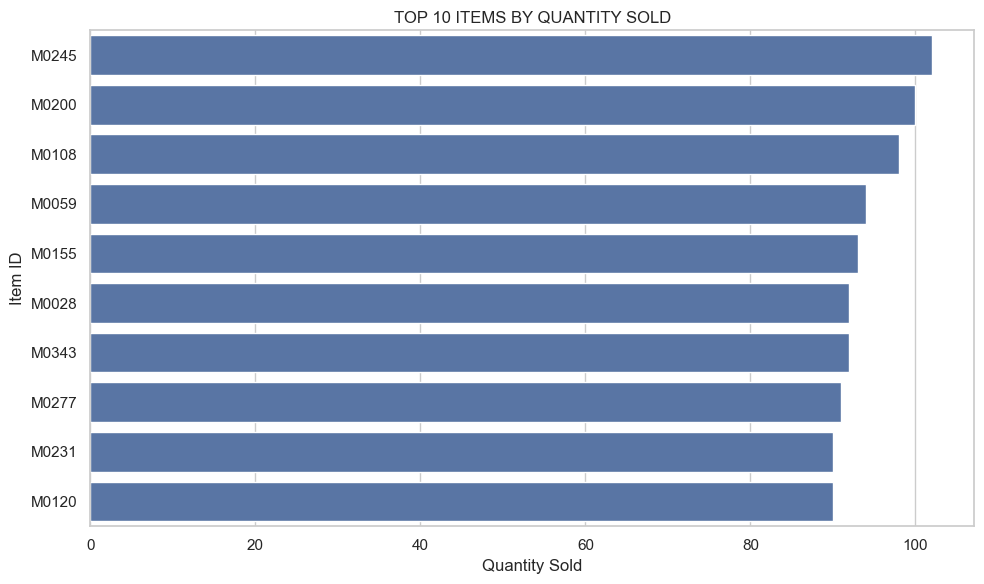

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_items,
    y="item_id",
    x="total_quantity_sold"
)

plt.title("TOP 10 ITEMS BY QUANTITY SOLD")
plt.xlabel("Quantity Sold")
plt.ylabel("Item ID")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/top_items_by_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [72]:
item_revenue = (
    order_items
    .groupby("item_id")["item_revenue"]
    .sum()
    .reset_index(
        name="total_revenue"
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

top_items_revenue = (
    item_revenue.head(10)
)

top_items_revenue

,item_id,total_revenue
269,M0270,3513.60
107,M0108,3470.18
180,M0181,3412.14
213,M0214,3375.68
119,M0120,3267.00
304,M0305,3180.56
338,M0339,3143.41
77,M0078,2986.90
152,M0153,2901.75
4,M0005,2881.76


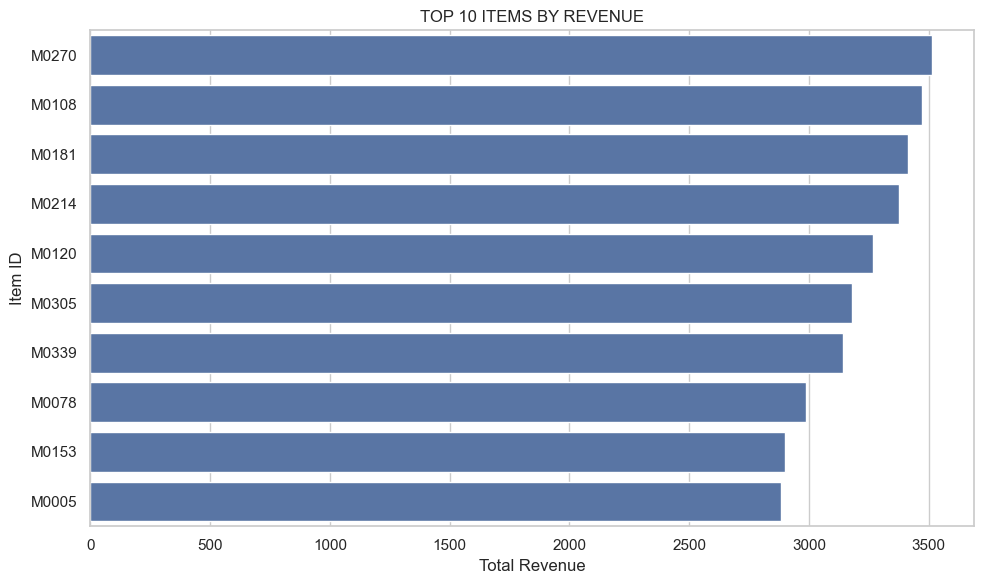

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_items_revenue,
    y="item_id",
    x="total_revenue"
)

plt.title("TOP 10 ITEMS BY REVENUE")
plt.xlabel("Total Revenue")
plt.ylabel("Item ID")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/top_items_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [74]:
restaurant_menu_size = (
    menu_items
    .groupby("restaurant_id")
    .size()
    .reset_index(
        name="menu_item_count"
    )
    .sort_values(
        "menu_item_count",
        ascending=False
    )
)

restaurant_menu_size.head(10)

,restaurant_id,menu_item_count
12,R013,9
95,R099,8
44,R046,8
15,R016,7
30,R031,6
45,R047,6
91,R095,6
34,R036,6
106,R110,6
71,R074,6


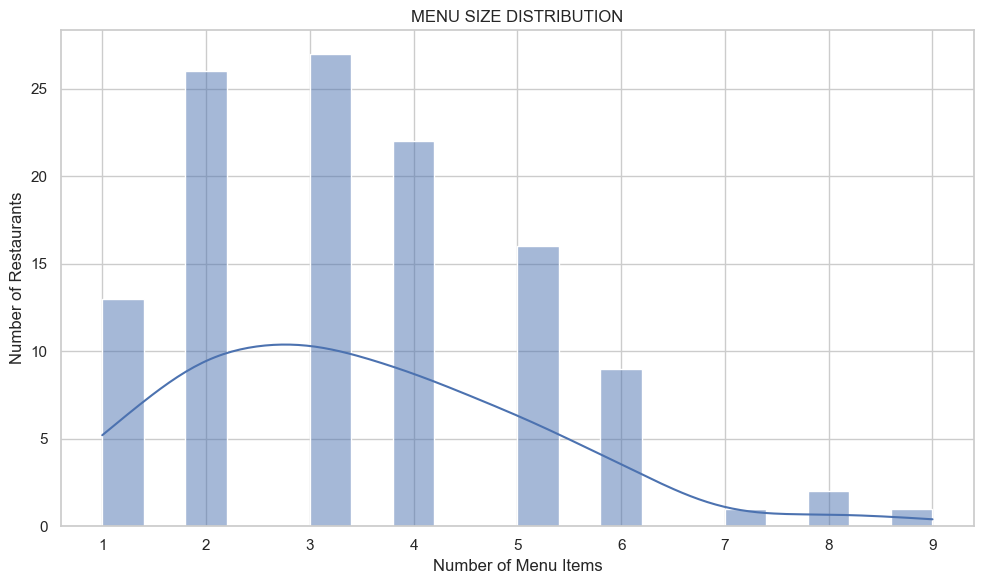

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=restaurant_menu_size,
    x="menu_item_count",
    bins=20,
    kde=True
)

plt.title("MENU SIZE DISTRIBUTION")
plt.xlabel("Number of Menu Items")
plt.ylabel("Number of Restaurants")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/menu_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [77]:
city_customers = (
    customers
    .groupby("city")
    .size()
    .reset_index(
        name="customer_count"
    )
    .sort_values(
        "customer_count",
        ascending=False
    )
)

city_customers

,city,customer_count
1,Bristol,270
2,Leeds,252
3,Liverpool,247
4,London,246
0,Birmingham,245
5,Manchester,240


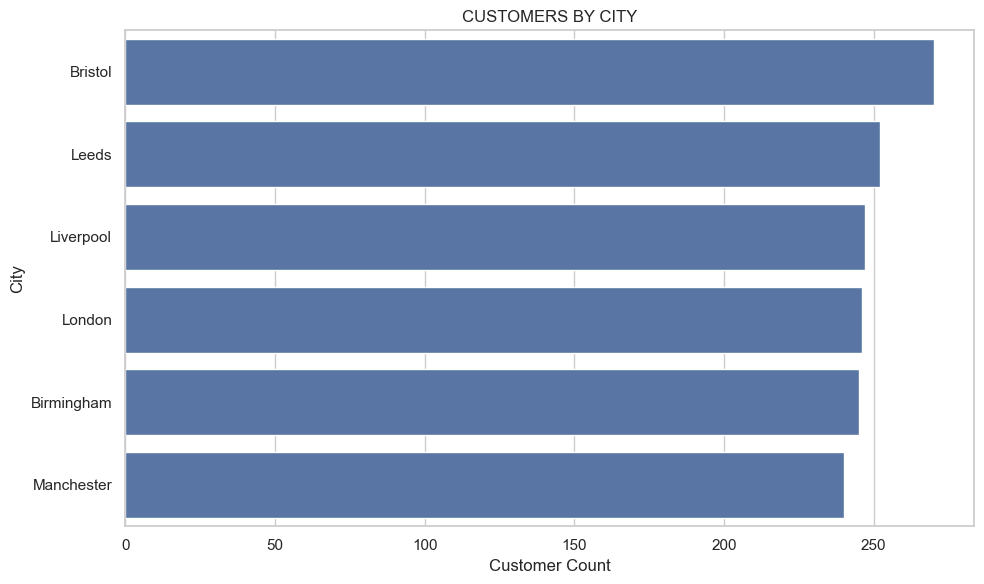

In [78]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_customers,
    y="city",
    x="customer_count"
)

plt.title("CUSTOMERS BY CITY")
plt.xlabel("Customer Count")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/customers_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [79]:
orders_city = (
    orders
    .merge(
        customers[
            [
                "customer_id",
                "city"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .groupby("city")
    .size()
    .reset_index(
        name="total_orders"
    )
    .sort_values(
        "total_orders",
        ascending=False
    )
)

orders_city

,city,total_orders
1,Bristol,959
2,Leeds,849
3,Liverpool,813
4,London,802
0,Birmingham,797
5,Manchester,780


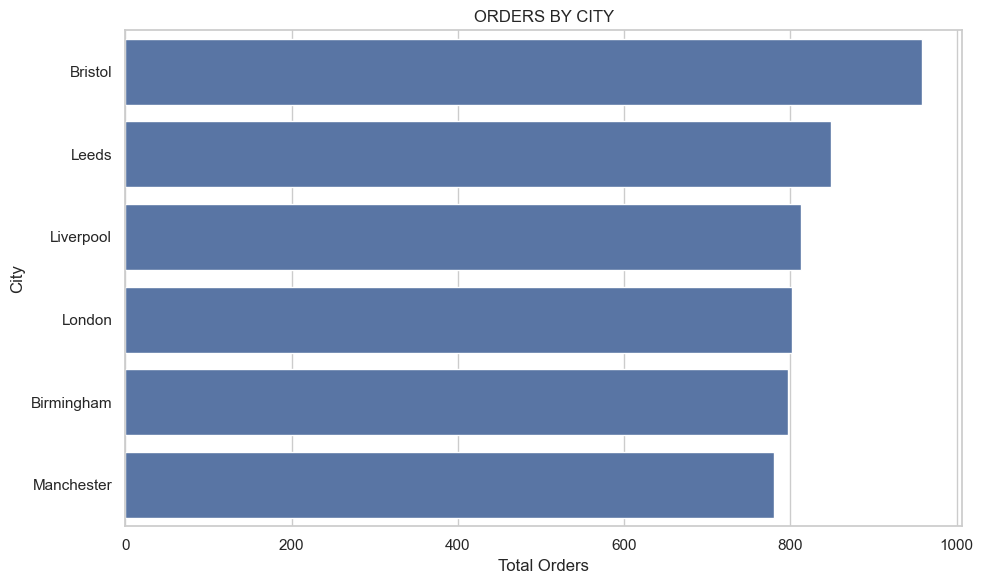

In [80]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=orders_city,
    y="city",
    x="total_orders"
)

plt.title("ORDERS BY CITY")
plt.xlabel("Total Orders")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/orders_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [81]:
restaurant_analysis = (
    restaurant_orders
    .groupby(
        [
            "restaurant_id",
            "rating"
        ]
    )
    .agg(
        total_orders=(
            "order_id",
            "count"
        ),
        avg_delivery_time=(
            "delivery_time_minutes",
            "mean"
        )
    )
    .reset_index()
)

correlation_matrix = (
    restaurant_analysis[
        [
            "rating",
            "total_orders",
            "avg_delivery_time"
        ]
    ]
    .corr()
)

correlation_matrix

,rating,total_orders,avg_delivery_time
rating,1.000000,0.024704,-0.077132
total_orders,0.024704,1.000000,0.171164
avg_delivery_time,-0.077132,0.171164,1.000000


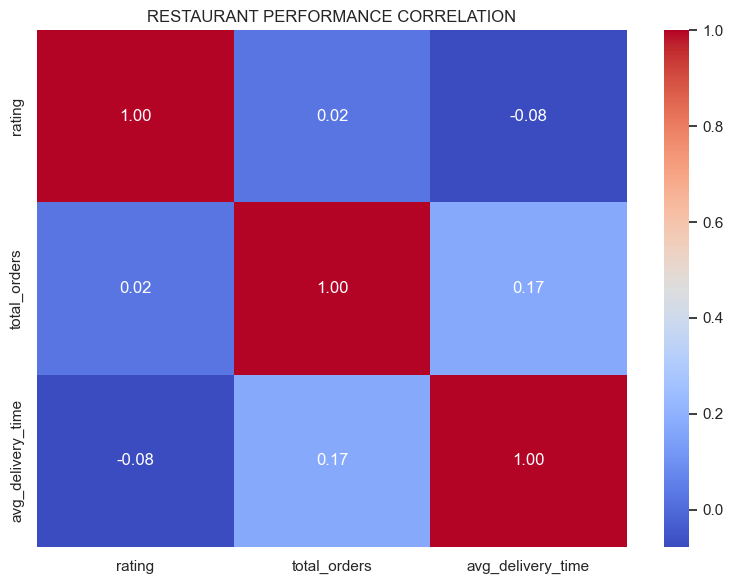

In [82]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("RESTAURANT PERFORMANCE CORRELATION")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/restaurant_performance_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [83]:
total_customers = (
    customers["customer_id"].nunique()
)

active_customers = (
    orders["customer_id"].nunique()
)

total_orders = (
    orders["order_id"].nunique()
)

total_restaurants = (
    restaurants["restaurant_id"].nunique()
)

total_menu_items = (
    menu_items["item_id"].nunique()
)

total_items_sold = (
    order_items["quantity"].sum()
)

total_revenue = (
    order_items["item_revenue"].sum()
)

average_order_value = (
    total_revenue /
    total_orders
)

average_delivery_time = (
    orders["delivery_time_minutes"].mean()
)

In [84]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Active Customers",
        "Total Orders",
        "Total Restaurants",
        "Total Menu Items",
        "Total Items Sold",
        "Total Revenue",
        "Average Order Value",
        "Average Delivery Time"
    ],
    "Value": [
        total_customers,
        active_customers,
        total_orders,
        total_restaurants,
        total_menu_items,
        total_items_sold,
        round(total_revenue, 2),
        round(average_order_value, 2),
        round(average_delivery_time, 2)
    ]
})

summary

,Metric,Value
0,Total Customers,1500.00
1,Active Customers,1452.00
2,Total Orders,5000.00
3,Total Restaurants,120.00
4,Total Menu Items,400.00
5,Total Items Sold,24699.00
6,Total Revenue,560509.15
7,Average Order Value,112.10
8,Average Delivery Time,54.62
